In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/HR_Dataset_Clean.csv')

In [2]:
df.shape

(3000, 36)

In [3]:
training_cols = ['Training Program Name', 'Training Type', 'Training Outcome',
                  'Trainer', 'Training Duration(Days)', 'Training Cost']
df[training_cols].describe(include='all')

,Training Program Name,Training Type,Training Outcome,Trainer,Training Duration(Days),Training Cost
count,3000,3000,3000,3000,3000.000000,3000.000000
unique,5,2,4,2942,NaN,NaN
top,Communication Skills,Internal,Incomplete,Michael Smith,NaN,NaN
freq,673,1509,775,4,NaN,NaN
mean,NaN,NaN,NaN,NaN,2.975667,558.628697
std,NaN,NaN,NaN,NaN,1.417890,263.217698
min,NaN,NaN,NaN,NaN,1.000000,100.040000
25%,NaN,NaN,NaN,NaN,2.000000,327.587500
50%,NaN,NaN,NaN,NaN,3.000000,572.125000
75%,NaN,NaN,NaN,NaN,4.000000,786.987500


In [4]:
df['Training Outcome'].value_counts()

Training Outcome
Incomplete    775
Completed     770
Passed        739
Failed        716
Name: count, dtype: int64

In [5]:
df.groupby('Training Type')[['Training Cost', 'Training Duration(Days)']].mean()

,Training Cost,Training Duration(Days)
Training Type,,
External,556.818008,2.952381
Internal,560.417787,2.998675


In [7]:
df.groupby('Training Outcome')[['Performance Score', 'Satisfaction Score', 'Engagement Score']].agg(
    lambda x: x.mode()[0] if x.name == 'Performance Score' else x.mean()
)

,Performance Score,Satisfaction Score,Engagement Score
Training Outcome,,,
Completed,Fully Meets,3.076623,2.955844
Failed,Fully Meets,3.004190,2.948324
Incomplete,Fully Meets,2.988387,2.947097
Passed,Fully Meets,3.017591,2.906631


In [8]:
df.groupby('Training Outcome')[['Satisfaction Score', 'Engagement Score', 'Work-Life Balance Score']].mean()

,Satisfaction Score,Engagement Score,Work-Life Balance Score
Training Outcome,,,
Completed,3.076623,2.955844,2.968831
Failed,3.004190,2.948324,2.972067
Incomplete,2.988387,2.947097,3.054194
Passed,3.017591,2.906631,2.958051


In [9]:
pd.crosstab(df['Training Outcome'], df['Performance Score'], normalize='index') * 100

Performance Score,Exceeds,Fully Meets,Needs Improvement,PIP
Training Outcome,,,,
Completed,12.987013,77.272727,6.363636,3.376623
Failed,11.592179,79.748603,5.446927,3.212291
Incomplete,11.225806,81.290323,5.290323,2.193548
Passed,13.396482,76.454668,6.495264,3.653586


In [11]:
total_cost = df['Training Cost'].sum()
failed_incomplete_cost = df[df['Training Outcome'].isin(['Failed', 'Incomplete'])]['Training Cost'].sum()
print(f"Celkové náklady na školení: ${total_cost:,.2f}")
print(f"Náklady na neúspěšná/nedokončená školení: ${failed_incomplete_cost:,.2f}")
print(f"Podíl 'promarněných' nákladů: {failed_incomplete_cost/total_cost*100:.1f}%")

Celkové náklady na školení: $1,675,886.09
Náklady na neúspěšná/nedokončená školení: $828,402.33
Podíl 'promarněných' nákladů: 49.4%


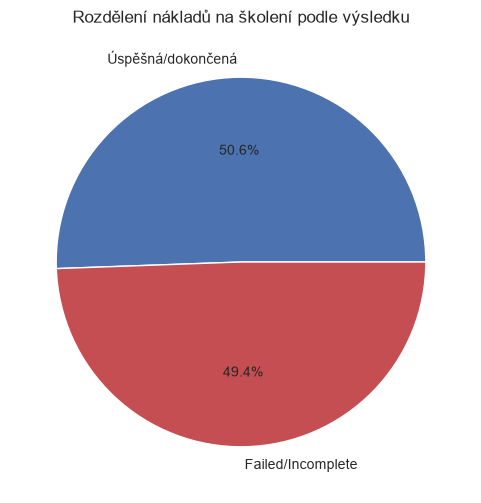

In [12]:
import matplotlib.pyplot as plt

labels = ['Úspěšná/dokončená', 'Failed/Incomplete']
values = [total_cost - failed_incomplete_cost, failed_incomplete_cost]

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'])
plt.title('Rozdělení nákladů na školení podle výsledku')
plt.savefig('../visuals/training_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()